[](http://)# TİTANİC
![](http://static3.thetravelimages.com/wordpress/wp-content/uploads/2018/11/titanic1-e1542497861799.jpg)



# 1- History

# **The RMS Titanic, a luxury steamship, sank in the early hours of April 15, 1912, off the coast of Newfoundland in the North Atlantic after sideswiping an iceberg during its maiden voyage. Of the 2,240 passengers and crew on board, more than 1,500 lost their lives in the disaster.**




# If you are using the kaggle first time

# This github link is for [https://github.com/nurrturkaslan](http://)

# In this github link I explain everything I did in general when I first started Data Science.


# 2- Exploring the data

# The files we read in the previous screen are available on the data page for the Titanic competition on Kaggle. That page also has a data dictionary, which explains the various columns that make up the data set. Below are the descriptions contained in that data dictionary:

# PassengerID - A column added by Kaggle to identify each row and make submissions easier
# Survived - Whether the passenger survived or not and the value we are predicting (0=No, 1=Yes)
# Pclass - The class of the ticket the passenger purchased (1=1st, 2=2nd, 3=3rd)
# Sex - The passenger's sex
# Age - The passenger's age in years
# SibSp - The number of siblings or spouses the passenger had aboard the Titanic
# Parch - The number of parents or children the passenger had aboard the Titanic
# Ticket - The passenger's ticket number
# Fare - The fare the passenger paid
# Cabin - The passenger's cabin number
# Embarked - The port where the passenger embarked (C=Cherbourg, Q=Queenstown, S=Southampton)

# DATA VİSUALİZATİON AND PREPROCESSİNG

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv


In [3]:
train_df = pd.read_csv("../input/titanic/train.csv")

In [4]:
numeric_data = train_df.iloc[:, [0,1,2,5,6,7,9]]
numeric_data.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [5]:
category_data = train_df.iloc[:, [3,4,8,10,11]]
category_data.head()

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3669: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


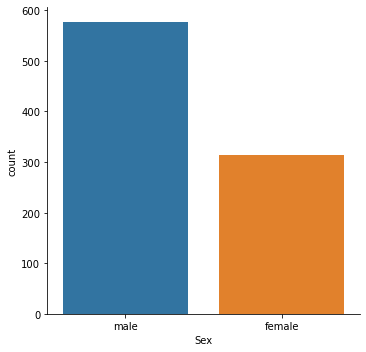

In [6]:
sns.factorplot("Sex", data = train_df, kind = "count")

> We can see above that the number of males is almost twice the number of females, but everyone knows that the number of surviving females is higher than the number of surviving males.

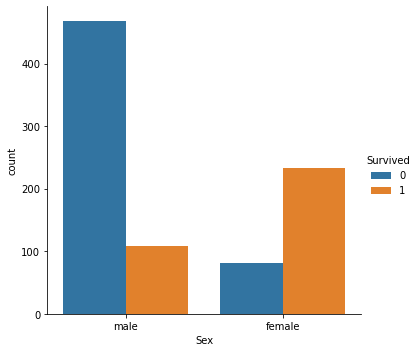

In [7]:
sns.factorplot("Sex", kind = "count", data = train_df, hue = "Survived")

> By visualizing the number of survival factor, we can examine survival / non-survival status by gender. Again, we can do it using factorplot () and adding another parameter with hue as above.

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3669: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


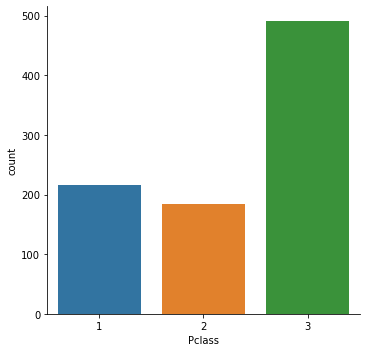

In [8]:
sns.factorplot("Pclass", data = train_df, kind = "count")

> A column represents the class reserved for each passenger. For example; 1 = First class 2 or 3 When we look at the graph, we can see that almost half of the passenger is in the third class. I think the most logical All Passengers are in third class, always in an expensive transport

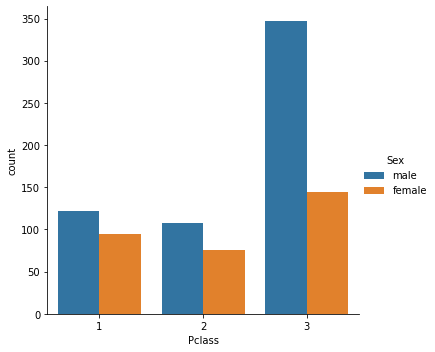

In [9]:
sns.factorplot("Pclass", data = train_df, hue = "Sex", kind = "count")

> Now let's see the Sex number over Pclass. We will do the same thing we did before. In the first and second grades, the number of males is almost equal to the number of females, but in the third grade the number of males almost doubles.

In [10]:
def titanic_children(passenger):
    age, sex = passenger
    if age < 16:
        return "child"
    else:
        return sex
train_df["person"] = train_df[["Age","Sex"]].apply(titanic_children, axis = 1)

> We need to extract more features, considering that we will create new columns containing hidden information. For example, when we need to calculate the number of children on board, we can subtract it from the Age column with some associations from the Sex column. and we will save it in the Person column like the above code.

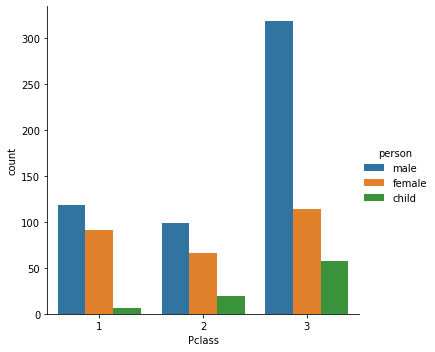

In [11]:
sns.factorplot("Pclass", data = train_df, hue = "person", kind = "count")

> As we can see, the number of children in third grade is huge compared to first and second grade. But the number of men is almost the same. In this case, we can look at what the total number of people per year is.

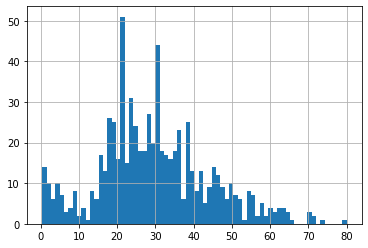

In [12]:
train_df["Age"].hist(bins = 70)

> We can do this with the hist () function, which calculates the histogram of the age, as seen in the code snippet above. It is simply counting the frequency of the variable in range.

> As we can see, the frequency of people on board between 16 and 35 years old is greater than the age or child above.

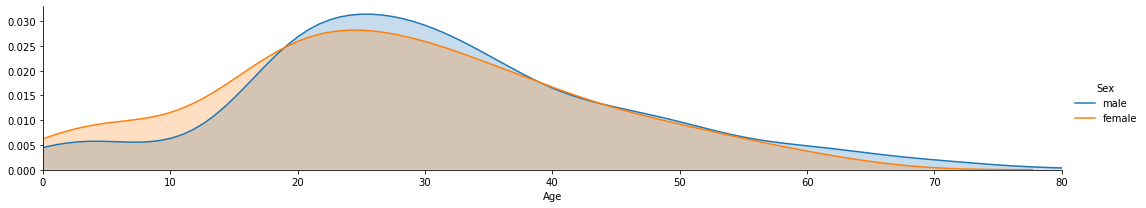

In [13]:
as_fig = sns.FacetGrid(train_df, hue="Sex", aspect = 5)
as_fig.map(sns.kdeplot, "Age", shade = True)
oldest = train_df["Age"].max()
as_fig.set(xlim = (0, oldest))
as_fig.add_legend()

> Now let's go one step further and count the frequency of men / women per age. We do this by stacking multiple figures together, creating something called the FacetGrid. This FacetGrid, which consists of two tables each, is the kdeplot type representing man and woman.

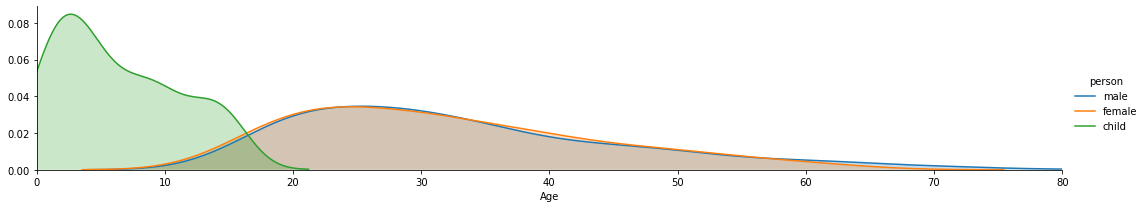

In [14]:
as_fig = sns.FacetGrid(train_df, hue="person", aspect = 5)
as_fig.map(sns.kdeplot, "Age", shade = True)
oldest = train_df["Age"].max()
as_fig.set(xlim = (0, oldest))
as_fig.add_legend()

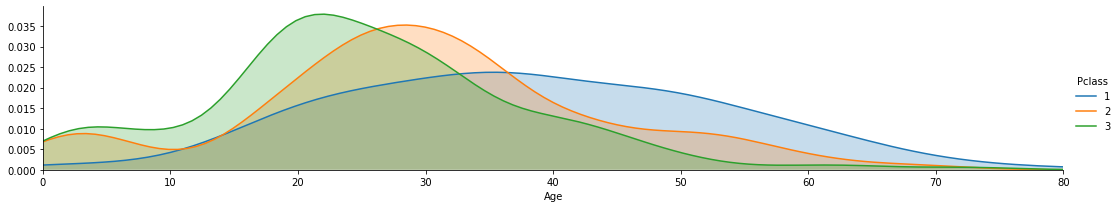

In [15]:
as_fig = sns.FacetGrid(train_df, hue="Pclass", aspect = 5)
as_fig.map(sns.kdeplot, "Age", shade = True)
oldest = train_df["Age"].max()
as_fig.set(xlim = (0, oldest))
as_fig.add_legend()

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3669: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


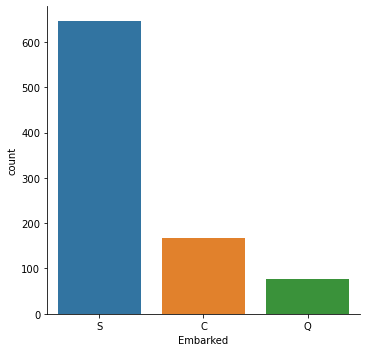

In [16]:
train_df["Embarked"] = train_df["Embarked"].fillna('S')
sns.factorplot("Embarked", data = train_df, kind = 'count')

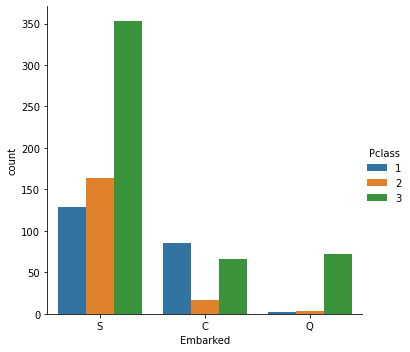

In [17]:
sns.factorplot("Embarked", data = train_df, hue = "Pclass", kind = "count")

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3669: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


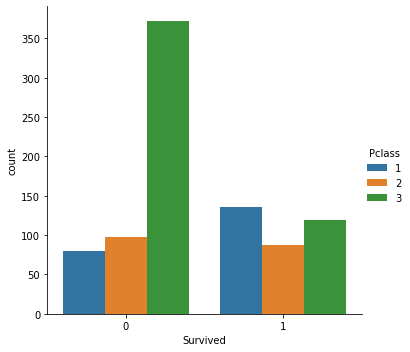

In [18]:
sns.factorplot("Survived", data = train_df, kind = "count", hue ="Pclass")

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3669: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


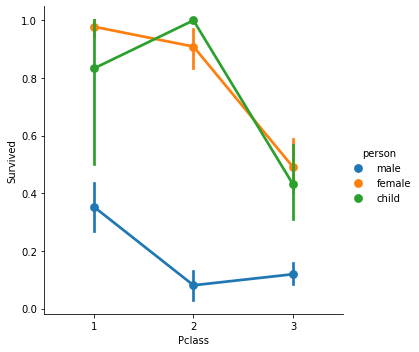

In [19]:
sns.factorplot("Pclass","Survived", data = train_df, hue = "person")

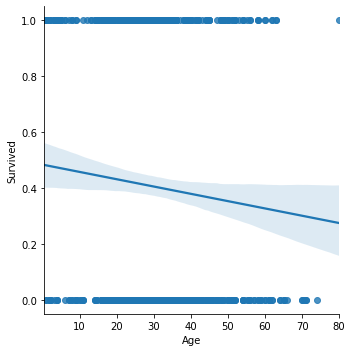

In [20]:
sns.lmplot("Age", "Survived", data = train_df)

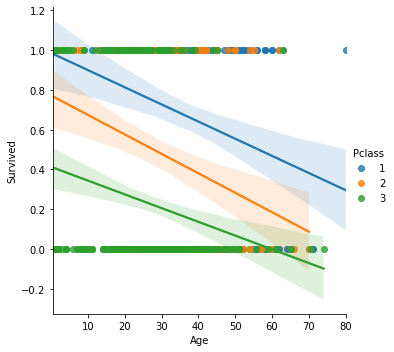

In [21]:
sns.lmplot("Age","Survived", data = train_df, hue = "Pclass")

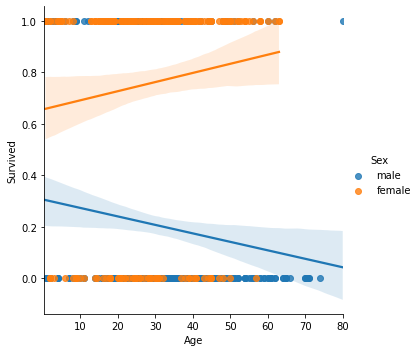

In [22]:
sns.lmplot("Age","Survived", data = train_df, hue = "Sex")

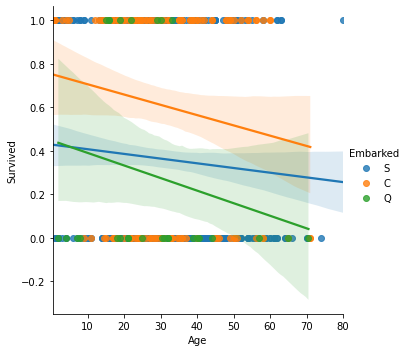

In [23]:
sns.lmplot("Age","Survived", data = train_df, hue = "Embarked")

# DATA PREPROCESSİNG

In [87]:
# Import modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import re
from sklearn import tree
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from ycimpute.imputer import knnimput

# Figures inline and set visualization style
%matplotlib inline
sns.set()


# Import data
train_df = pd.read_csv("../input/titanic/train.csv")
test_df = pd.read_csv("../input/titanic/test.csv")

In [88]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [89]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [90]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [91]:
train_df["Survived"].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [92]:
train_df["Pclass"].value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

In [93]:
train_df["Age"].value_counts()

24.00    30
22.00    27
18.00    26
19.00    25
30.00    25
         ..
55.50     1
70.50     1
66.00     1
23.50     1
0.42      1
Name: Age, Length: 88, dtype: int64

In [94]:
train_df["SibSp"].value_counts()

0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64

In [95]:
train_df["Parch"].value_counts()

0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64

In [96]:
train_df["Fare"].value_counts()

8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
8.4583      1
9.8375      1
8.3625      1
14.1083     1
17.4000     1
Name: Fare, Length: 248, dtype: int64

# OUTLİER TREATMENT

In [97]:
df_fare = train_df["Fare"]
df_fare.head()

0     7.2500
1    71.2833
2     7.9250
3    53.1000
4     8.0500
Name: Fare, dtype: float64

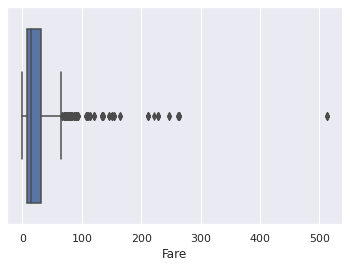

In [98]:
sns.boxplot(x = df_fare);

In [99]:
Q1 = df_fare.quantile(0.25)
Q3 = df_fare.quantile(0.75)
IQR = Q3 - Q1

In [100]:
Q1

7.9104

In [101]:
Q3

31.0

In [102]:
IQR

23.0896

In [103]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

In [104]:
lower_limit

-26.724

In [105]:
upper_limit

65.6344

In [106]:
(df_fare < lower_limit) | (df_fare > upper_limit)

0      False
1       True
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Fare, Length: 891, dtype: bool

In [107]:
outlier_tf = (df_fare > upper_limit)
outlier_tf.head()

0    False
1     True
2    False
3    False
4    False
Name: Fare, dtype: bool

In [108]:
df_fare[outlier_tf]

1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64

In [109]:
df_fare[outlier_tf].index

Int64Index([  1,  27,  31,  34,  52,  61,  62,  72,  88, 102,
            ...
            792, 802, 820, 829, 835, 846, 849, 856, 863, 879],
           dtype='int64', length=116)

In [110]:
type(df_fare)

pandas.core.series.Series

In [111]:
df_fare = pd.DataFrame(df_fare)

In [112]:
df_fare.shape

(891, 1)

In [113]:
clear_tf = df_fare[~((df_fare < (lower_limit)) | (df_fare > (upper_limit)).any(axis=1))]

In [114]:
clear_tf.shape

# 116 observations flew. When we evaluate our observation in two ways.

(891, 1)

# SUPPRESSİON

In [115]:
df_fare = train_df["Fare"]

In [116]:
lower_limit

-26.724

In [117]:
df_fare[outlier_tf]

1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64

In [118]:
upper_limit

65.6344

In [119]:
df_fare[outlier_tf] = upper_limit

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [120]:
df_fare[outlier_tf] 

# I suppressed the values above the upper limit value to the upper limit value, that is, we have suppressed the values above our threshold value according to our threshold value.

1      65.6344
27     65.6344
31     65.6344
34     65.6344
52     65.6344
        ...   
846    65.6344
849    65.6344
856    65.6344
863    65.6344
879    65.6344
Name: Fare, Length: 116, dtype: float64

# LOCAL OUTLİER FACTOR (LOF)

# It allows us to define values that may be outliers by scoring the observations based on density at their location. The local density of these points is compared with the neighbors of these points. If it is significantly lower than the density of its neighbors, it can be interpreted that this point is located in a less frequent area than the neighbors. Therefore, there is a neighborhood structure here and if the environment of a value is not intense, it means that this value is evaluated as an outlier. In short, we can say that it scores for each observation value.

In [121]:
train_df = train_df.select_dtypes(include = ["float64", "int64"])
df = train_df.copy()
df= df.dropna()
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,65.6344
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [122]:
clf = LocalOutlierFactor(n_neighbors = 20, contamination = 0.1)

# n_neighbors: refers to the neighborhood number.
#contamination: an argument expressing density

In [123]:
clf.fit_predict(df)

# The clf object contains the formal properties of lOFT.
# We perform algorithm execution.

array([ 1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1, -1,  1, -1, -1, -1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,
       -1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
       -1,  1,  1,  1, -1

In [124]:
df_scores = clf.negative_outlier_factor_

In [125]:
df_scores[0:10]

# the score of each observation unit we have, i.e. the density score or LOF score

array([-1.04816255, -1.31865192, -1.02667364, -1.1510118 , -1.03172692,
       -1.17425827, -1.07908238, -1.01014533, -1.01508226, -1.05556827])

In [126]:
np.sort(df_scores)[0:20]

# We sorted the df scores with the sort function

array([-1.65016854, -1.62858181, -1.60648569, -1.5876836 , -1.58669811,
       -1.56828196, -1.56690089, -1.49927922, -1.48586557, -1.44697059,
       -1.44488949, -1.418858  , -1.41408645, -1.40629699, -1.39089257,
       -1.37436006, -1.3710148 , -1.36021691, -1.34612898, -1.33295214])

In [127]:
threshold_value = np.sort(df_scores)[9]

In [128]:
outlier_tf = df_scores > threshold_value

# I saved those above the threshold as outlier_tf

In [129]:
outlier_tf

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [130]:
new_df = df[df_scores > threshold_value]

# We took all that fulfill this condition that is above the threshold.
# that means accessing non-outlier values and deleting outliers.

In [131]:
new_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,65.6344
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
885,886,0,3,39.0,0,5,29.1250
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
889,890,1,1,26.0,0,0,30.0000


In [132]:
df[df_scores < threshold_value]

# When I reverse it, we see contrary observations.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
96,97,0,1,71.0,0,0,34.6542
116,117,0,3,70.5,0,0,7.7500
195,196,1,1,58.0,0,0,65.6344
435,436,1,1,14.0,1,2,65.6344
438,439,0,1,64.0,1,4,65.6344
445,446,1,1,4.0,0,2,65.6344
630,631,1,1,80.0,0,0,30.0000
851,852,0,3,74.0,0,0,7.7750
879,880,1,1,56.0,0,1,65.6344


# Note: While applying the box plot method, when we observed the outlier_tf up and down compared to the mouse variable, we had too many observations, but we reached a less limited number of observations in LOF. In fact, it would be more correct if I said we applied a deletion method.

# SUPPRESSİON

> It may be the most logical approach in LOF to perform the assignment according to the values in the index of the threshold value we have determined.

In [133]:
df[df_scores == threshold_value]

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
215,216,1,1,31.0,1,0,65.6344


> It was the threshold value we set above.
How we determined the threshold value We created a density-based score that we call the LOF score.
We saved it as df_scores and from there I set the 9th index as the threshold value.
We observe its equivalent as a numerical value above now.

In [134]:
print_worth = df[df_scores == threshold_value]

# I saved it as the hang value;
# Our aim is to perform the filling process according to this observation unit.

In [135]:
outliers = df[~outlier_tf]

# I'm also recording the outliers

> The goal is to replace outliers with print values and I'll do that.

Now, I will take action to solve the index problem in the outliers section above. After converting the outliers dataframe I named to an array without an index, we will arrange the print value, ie print_worth, and replace the last outliers with print_worth.

In [136]:
outliers

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
96,97,0,1,71.0,0,0,34.6542
116,117,0,3,70.5,0,0,7.7500
195,196,1,1,58.0,0,0,65.6344
215,216,1,1,31.0,1,0,65.6344
435,436,1,1,14.0,1,2,65.6344
438,439,0,1,64.0,1,4,65.6344
445,446,1,1,4.0,0,2,65.6344
630,631,1,1,80.0,0,0,30.0000
851,852,0,3,74.0,0,0,7.7750
879,880,1,1,56.0,0,1,65.6344


In [137]:
res = outliers.to_records(index = False)

In [138]:
res[:] = print_worth.to_records(index = False)

In [139]:
res

rec.array([(216, 1, 1, 31., 1, 0, 65.6344),
           (216, 1, 1, 31., 1, 0, 65.6344),
           (216, 1, 1, 31., 1, 0, 65.6344),
           (216, 1, 1, 31., 1, 0, 65.6344),
           (216, 1, 1, 31., 1, 0, 65.6344),
           (216, 1, 1, 31., 1, 0, 65.6344),
           (216, 1, 1, 31., 1, 0, 65.6344),
           (216, 1, 1, 31., 1, 0, 65.6344),
           (216, 1, 1, 31., 1, 0, 65.6344),
           (216, 1, 1, 31., 1, 0, 65.6344)],
          dtype=[('PassengerId', '<i8'), ('Survived', '<i8'), ('Pclass', '<i8'), ('Age', '<f8'), ('SibSp', '<i8'), ('Parch', '<i8'), ('Fare', '<f8')])

In [140]:
df[~outlier_tf]

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
96,97,0,1,71.0,0,0,34.6542
116,117,0,3,70.5,0,0,7.7500
195,196,1,1,58.0,0,0,65.6344
215,216,1,1,31.0,1,0,65.6344
435,436,1,1,14.0,1,2,65.6344
438,439,0,1,64.0,1,4,65.6344
445,446,1,1,4.0,0,2,65.6344
630,631,1,1,80.0,0,0,30.0000
851,852,0,3,74.0,0,0,7.7750
879,880,1,1,56.0,0,1,65.6344


In [141]:
df[~outlier_tf] = pd.DataFrame(res, index = df[~outlier_tf].index)

In [142]:
df[~outlier_tf]

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
96,216,1,1,31.0,1,0,65.6344
116,216,1,1,31.0,1,0,65.6344
195,216,1,1,31.0,1,0,65.6344
215,216,1,1,31.0,1,0,65.6344
435,216,1,1,31.0,1,0,65.6344
438,216,1,1,31.0,1,0,65.6344
445,216,1,1,31.0,1,0,65.6344
630,216,1,1,31.0,1,0,65.6344
851,216,1,1,31.0,1,0,65.6344
879,216,1,1,31.0,1,0,65.6344


# FİLLİNG İN MİSSİNG OBSERVATİONS WİTH MACHİNE LEARNİNG ALGORİTHMS

# KNN

In [143]:
from sklearn.impute import KNNImputer
train_df = train_df.select_dtypes(include = ["float64","int64"])
train_df.head(20)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,65.6344
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
5,6,0,3,NaN,0,0,8.4583
6,7,0,1,54.0,0,0,51.8625
7,8,0,3,2.0,3,1,21.0750
8,9,1,3,27.0,0,2,11.1333
9,10,1,2,14.0,1,0,30.0708


In [144]:
!pip install ycimpute

In [145]:
var_names = list(train_df)

# to keep the names of the variables I keep the names of the dataframe somewhere.

In [146]:
n_df = np.array(train_df)

# I'm creating a new array

In [147]:
n_df[0:10]

array([[ 1.    ,  0.    ,  3.    , 22.    ,  1.    ,  0.    ,  7.25  ],
       [ 2.    ,  1.    ,  1.    , 38.    ,  1.    ,  0.    , 65.6344],
       [ 3.    ,  1.    ,  3.    , 26.    ,  0.    ,  0.    ,  7.925 ],
       [ 4.    ,  1.    ,  1.    , 35.    ,  1.    ,  0.    , 53.1   ],
       [ 5.    ,  0.    ,  3.    , 35.    ,  0.    ,  0.    ,  8.05  ],
       [ 6.    ,  0.    ,  3.    ,     nan,  0.    ,  0.    ,  8.4583],
       [ 7.    ,  0.    ,  1.    , 54.    ,  0.    ,  0.    , 51.8625],
       [ 8.    ,  0.    ,  3.    ,  2.    ,  3.    ,  1.    , 21.075 ],
       [ 9.    ,  1.    ,  3.    , 27.    ,  0.    ,  2.    , 11.1333],
       [10.    ,  1.    ,  2.    , 14.    ,  1.    ,  0.    , 30.0708]])

In [148]:
n_df.shape

# number of observations and variables

(891, 7)

In [149]:
dff = knnimput.KNN(k=4).complete(n_df)

# neighborhood number = 4, complete: means fill
# He filled the observations he saw missing

Imputing row 1/891 with 0 missing, elapsed time: 0.135
Imputing row 101/891 with 0 missing, elapsed time: 0.137
Imputing row 201/891 with 0 missing, elapsed time: 0.138
Imputing row 301/891 with 1 missing, elapsed time: 0.139
Imputing row 401/891 with 0 missing, elapsed time: 0.140
Imputing row 501/891 with 0 missing, elapsed time: 0.141
Imputing row 601/891 with 0 missing, elapsed time: 0.142
Imputing row 701/891 with 0 missing, elapsed time: 0.144
Imputing row 801/891 with 0 missing, elapsed time: 0.145


In [150]:
type(dff)

numpy.ndarray

In [151]:
dff = pd.DataFrame(dff, columns = var_names)

# Convert to pandas dataframe...

In [152]:
type(dff)

pandas.core.frame.DataFrame

# EM

In [153]:
train_df = train_df.select_dtypes(include = ["float64","int64"])
train_df.head(20)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,65.6344
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
5,6,0,3,NaN,0,0,8.4583
6,7,0,1,54.0,0,0,51.8625
7,8,0,3,2.0,3,1,21.0750
8,9,1,3,27.0,0,2,11.1333
9,10,1,2,14.0,1,0,30.0708


In [154]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64

In [155]:
var_names = list(train_df)

In [156]:
n_df = np.array(train_df)

In [157]:
from ycimpute.imputer import EM

In [158]:
dff = EM().complete(n_df)

In [159]:
dff = pd.DataFrame(dff, columns = var_names)

In [160]:
dff.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64

# footnote: even if we filled in the missing values with predictive methods in this way; Is there a structural problem before or is there a randomness problem? Are deficiencies in some variables dependent on other variables? Using these methods after examining and establishing the connection will give healthier results.

# Machine Learning Model

> How to create our machine learning model with a decision tree classifier with the Python scikit-learn package

In [161]:
train_df = pd.read_csv("../input/titanic/train.csv")
test_df = pd.read_csv("../input/titanic/test.csv")

In [162]:
survived_train = train_df.Survived # store target variable of training data in a safe place

In [163]:
data = pd.concat([train_df.drop(["Survived"], axis = 1), test_df]) #concatenate training and test sets

In [164]:
data.head(20)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [165]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 122.7+ KB


> *There are 2 numerical variables that have missing values.

In [166]:
data["Age"] = data.Age.fillna(data.Age.median())
data["Fare"] = data.Fare.fillna(data.Fare.median())
# Impute missing numerical variables

In [167]:
data.info()
# Check out info of data

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1309 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1309 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 122.7+ KB


In [168]:
data = pd.get_dummies(data, columns = ["Sex"], drop_first = True)
data.head(20)

,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male
0,1,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,0
4,5,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,1
5,6,3,"Moran, Mr. James",28.0,0,0,330877,8.4583,NaN,Q,1
6,7,1,"McCarthy, Mr. Timothy J",54.0,0,0,17463,51.8625,E46,S,1
7,8,3,"Palsson, Master. Gosta Leonard",2.0,3,1,349909,21.0750,NaN,S,1
8,9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,0,2,347742,11.1333,NaN,S,0
9,10,2,"Nasser, Mrs. Nicholas (Adele Achem)",14.0,1,0,237736,30.0708,NaN,C,0


> 'Sex_male' column; this column has 1 if this row is a male and 0 if this row is female.

In [169]:
# Select columns and view head
data = data[['Sex_male', 'Fare', 'Age','Pclass', 'SibSp']]
data.head()

,Sex_male,Fare,Age,Pclass,SibSp
0,1,7.2500,22.0,3,1
1,0,71.2833,38.0,1,1
2,0,7.9250,26.0,3,0
3,0,53.1000,35.0,1,1
4,1,8.0500,35.0,3,0


In [170]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 417
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sex_male  1309 non-null   uint8  
 1   Fare      1309 non-null   float64
 2   Age       1309 non-null   float64
 3   Pclass    1309 non-null   int64  
 4   SibSp     1309 non-null   int64  
dtypes: float64(2), int64(2), uint8(1)
memory usage: 52.4 KB


# Decision Tree Classifier

>  It is a tree that allows you to classify data points, which are also known as target variables, based on feature variables.

In [171]:
data_train = data.iloc[:891]
data_test = data.iloc[891:]

In [172]:
X = data_train.values
test = data_test.values
y = survived_train.values

In [173]:
# Instantiate model and fit to data
clf = tree.DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=3)

> > Why Choose max_depth=3 ?
> > The depth of the tree is known as a hyperparameter, which means a parameter you need to decide before you fit the model to the data. If you choose a larger max_depth, you'll get a more complex decision boundary.

* If your decision boundary is too complex, you can overfit to the data, which means that your model will be describing noise as well as signal.

* If your max_depth is too small, you might be underfitting the data, meaning that your model doesn't contain enough of the signal.

In [174]:
# Make predictions and store in 'Survived' column of df_test
Y_pred = clf.predict(test)
test_df['Survived'] = Y_pred

> >Let's break down our original training data into training and test sets 

In [175]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

> > Now, let's iterate over the maximum depth values ranging from 1 to 9 and plot the accuracy of the models on training and test sets.

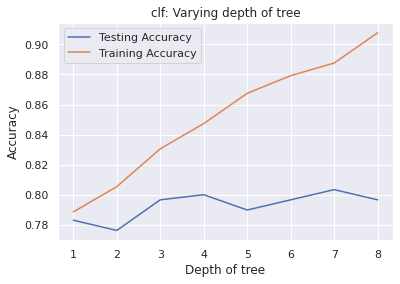

In [176]:
# Setup arrays to store train and test accuracies
dep = np.arange(1, 9)
train_accuracy = np.empty(len(dep))
test_accuracy = np.empty(len(dep))

# Loop over different values of k
for i, k in enumerate(dep):
    # Setup a Decision Tree Classifier
    clf = tree.DecisionTreeClassifier(max_depth=k)

    # Fit the classifier to the training data
    clf.fit(X_train, y_train)

    #Compute accuracy on the training set
    train_accuracy[i] = clf.score(X_train, y_train)

    #Compute accuracy on the testing set
    test_accuracy[i] = clf.score(X_test, y_test)

# Generate plot
plt.title('clf: Varying depth of tree')
plt.plot(dep, test_accuracy, label = 'Testing Accuracy')
plt.plot(dep, train_accuracy, label = 'Training Accuracy')
plt.legend()
plt.xlabel('Depth of tree')
plt.ylabel('Accuracy')
plt.show()

****As we increase the maximum depth, we will fit better and better with the exercise data because we will make decisions that define the exercise data. The accuracy of the exercise data will and will increase, but we see that this is not for test data: we are overly sleeping